# Round 1 Manual - Auction Mechanics First

This notebook models the manual auction exactly the way we needed to think about it during the round. The challenge was not to sweep visible edge. The challenge was to understand the single clearing price, the higher-price tie break, the queue priority, and the fact that our order was submitted last.

The goal is simple: search prices and quantities, show why the naive sweep loses, and confirm the final book we would defend: `DRYLAND_FLAX BUY 9,999 @ 30` and `EMBER_MUSHROOM BUY 19,999 @ 17`.


In [1]:
import matplotlib.pyplot as plt

books = {
    "DRYLAND_FLAX": {
        "buyback": 30.0,
        "fee": 0.0,
        "bids": {30: 30000, 29: 5000, 28: 12000, 27: 28000},
        "asks": {28: 40000, 31: 20000, 32: 20000, 33: 30000},
    },
    "EMBER_MUSHROOM": {
        "buyback": 20.0,
        "fee": 0.10,
        "bids": {20: 43000, 19: 17000, 18: 6000, 17: 5000, 16: 10000, 15: 5000, 14: 10000, 13: 7000},
        "asks": {12: 20000, 13: 25000, 14: 35000, 15: 6000, 16: 5000, 17: 0, 18: 10000, 19: 12000},
    },
}

def clearing_price(book, our_price=None, our_qty=0):
    prices = set(book["bids"]) | set(book["asks"])
    if our_price is not None and our_qty > 0:
        prices.add(our_price)
    best = None
    rows = []
    for c in sorted(prices):
        bid_vol = sum(v for p, v in book["bids"].items() if p >= c)
        if our_price is not None and our_price >= c:
            bid_vol += our_qty
        ask_vol = sum(v for p, v in book["asks"].items() if p <= c)
        traded = min(bid_vol, ask_vol)
        rows.append((c, bid_vol, ask_vol, traded))
        if best is None or traded > best[3] or (traded == best[3] and c > best[0]):
            best = (c, bid_vol, ask_vol, traded)
    return best[0], rows

def our_fill(book, our_price, our_qty):
    c, _ = clearing_price(book, our_price, our_qty)
    if our_price < c:
        return c, 0
    ask_supply = sum(v for p, v in book["asks"].items() if p <= c)
    ahead = sum(v for p, v in book["bids"].items() if p > our_price)
    ahead += book["bids"].get(our_price, 0)
    fill = max(0, min(our_qty, ask_supply - ahead))
    return c, fill

def profit(book, price, qty):
    c, fill = our_fill(book, price, qty)
    edge = book["buyback"] - c - book["fee"]
    return fill * edge, c, fill

for name, book in books.items():
    c, rows = clearing_price(book)
    print(name)
    print("clears without us at", c)
    for row in rows:
        print("  c=%s bids=%s asks=%s traded=%s" % row)
    print()


DRYLAND_FLAX
clears without us at 28
  c=27 bids=75000 asks=0 traded=0
  c=28 bids=47000 asks=40000 traded=40000
  c=29 bids=35000 asks=40000 traded=35000
  c=30 bids=30000 asks=40000 traded=30000
  c=31 bids=0 asks=60000 traded=0
  c=32 bids=0 asks=80000 traded=0
  c=33 bids=0 asks=110000 traded=0

EMBER_MUSHROOM
clears without us at 15
  c=12 bids=103000 asks=20000 traded=20000
  c=13 bids=103000 asks=45000 traded=45000
  c=14 bids=96000 asks=80000 traded=80000
  c=15 bids=86000 asks=86000 traded=86000
  c=16 bids=81000 asks=91000 traded=81000
  c=17 bids=71000 asks=91000 traded=71000
  c=18 bids=66000 asks=101000 traded=66000
  c=19 bids=60000 asks=113000 traded=60000
  c=20 bids=43000 asks=113000 traded=43000



In [2]:
search_ranges = {
    "DRYLAND_FLAX": (range(1, 36), range(0, 120001)),
    "EMBER_MUSHROOM": (range(1, 25), range(0, 140001)),
}

for name, book in books.items():
    prices, qtys = search_ranges[name]
    best = (-10**18, None, None, None, None)
    for p in prices:
        for q in qtys:
            pnl, c, f = profit(book, p, q)
            if pnl > best[0]:
                best = (pnl, p, q, c, f)
    print(name)
    print("best pnl=%.1f price=%s qty=%s clearing=%s fill=%s" % best)

print("Naive comparison")
for name, order in [("DRYLAND_FLAX", (28, 40000)), ("EMBER_MUSHROOM", (19, 113000))]:
    pnl, c, f = profit(books[name], *order)
    print("%s naive %s @ %s -> clearing %s fill %s pnl %.1f" % (name, order[1], order[0], c, f, pnl))


DRYLAND_FLAX
best pnl=9999.0 price=30 qty=9999 clearing=29 fill=9999


EMBER_MUSHROOM
best pnl=77996.1 price=17 qty=19999 clearing=16 fill=19999
Naive comparison
DRYLAND_FLAX naive 40000 @ 28 -> clearing 28 fill 0 pnl 0.0
EMBER_MUSHROOM naive 113000 @ 19 -> clearing 19 fill 53000 pnl 47700.0


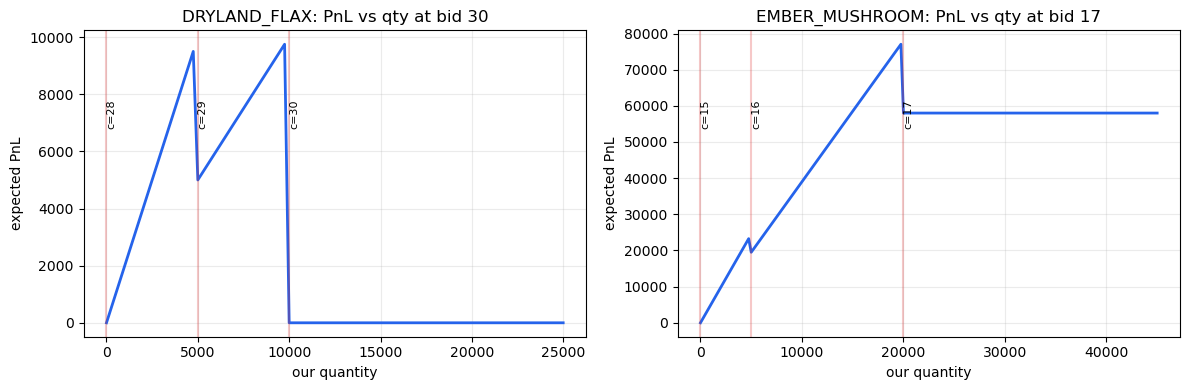

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, price, max_q) in zip(axes, [("DRYLAND_FLAX", 30, 25000), ("EMBER_MUSHROOM", 17, 45000)]):
    qs = list(range(0, max_q + 1, 250))
    pnls = [profit(books[name], price, q)[0] for q in qs]
    clears = [profit(books[name], price, q)[1] for q in qs]
    ax.plot(qs, pnls, color="#2563eb", lw=2)
    ax.set_title(f"{name}: PnL vs qty at bid {price}")
    ax.set_xlabel("our quantity")
    ax.set_ylabel("expected PnL")
    ax.grid(alpha=0.25)
    last = None
    for q, c in zip(qs, clears):
        if c != last:
            ax.axvline(q, color="#dc2626", alpha=0.25)
            ax.text(q, max(pnls) * 0.75, f"c={c}", rotation=90, va="center", fontsize=8)
            last = c
plt.tight_layout()
